In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = True

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
counts = df_tv['Irrigation_Need'].value_counts()
continous_variables = df_tv.select_dtypes(['float64']).columns

#balanced data set
df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# Downsample majority class
majority_downsampled = resample(df_tv_majority, 
                              replace=False,  # Sample without replacement
                              n_samples=len(df_tv_mid),  # Equalize class sizes
                              random_state=42)
# Oversample minority class
minority_upsampled = resample(df_tv_minority, 
                              replace=True,  # Sample with replacement
                              n_samples=len(df_tv_mid),  # Equalize class sizes
                              random_state=42)
# # Oversample mid class
# mid_upsampled = resample(df_tv_mid, 
#                          replace=True,  # Sample with replacement
#                          n_samples=len(df_tv_majority),  # Equalize class sizes
#                          random_state=42)
#df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
df_tv = df_balanced if balanced else df_tv



class_le = LabelEncoder()
y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

sc = StandardScaler().fit(df_dummy[continous_variables])
df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
x = df_dummy.to_numpy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(x, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)




In [ ]:
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)
mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                        n_estimators=2000, learning_rate=0.1, max_depth=5, reg_lambda=1, 
                        objective='multi:softmax', num_class=3, eval_metric='merror')
mxgb.fit(cupy.array(X_train), y_train)
mxgb.score(X_test, y_test)
#mxgb.fit(cupy.array(x), y)


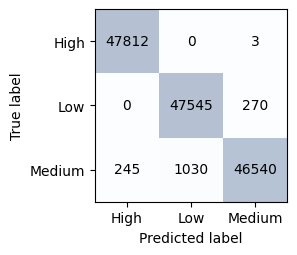

In [3]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

y_pred = mxgb.predict(cupy.array(X_test))
labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=0.1, solver='lbfgs', class_weight="balanced")
lr.fit(X_train, y_train)
test_acc = lr.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')


Test accuracy: 0.849


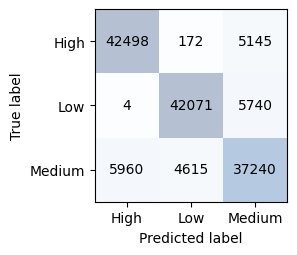

In [5]:
y_pred = lr.predict(X_test)
labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [6]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced")
dt.fit(X_train, y_train)
dt.score(X_test, y_test)

0.9783331590505072

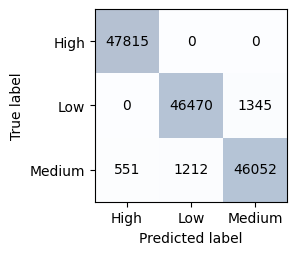

In [7]:
y_pred = dt.predict(X_test)
labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [1]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced")
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

NameError: name 'X_train' is not defined

In [ ]:
y_pred = rf.predict(X_test)
labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [7]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=5, reg_lambda=0.1,
                      boosting_type='dart')
lgbm.fit(X_train, y_train)
lgbm.score(X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 573777, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9775454006762173

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


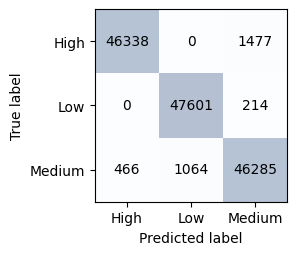

In [8]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

y_pred = lgbm.predict(X_test)
labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [ ]:
# from sklearn.ensemble import VotingClassifier

# voting_clf = VotingClassifier(estimators=[('rf', gsf), ('lr', lr)], voting='soft')
# voting_clf.fit(x, y)



In [4]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values

df_test_dummy = pd.get_dummies(df_test.iloc[:,1:])
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_mxgb = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(mxgb.predict(x_test))})
df_submission_mxgb.to_csv(os.path.join(out_dir, 'submission-mxgb_v4.csv'), index=False)